<a href="https://colab.research.google.com/github/the-lazyguy/brain-tumor-xai/blob/main/Brain_Tumor_ResNet50_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

DATASET_PATH = "/content/drive/MyDrive/brain_tumor_dataset"

print(os.listdir(DATASET_PATH))

['Training', 'Testing']


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
NUM_CLASSES = 4

model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights="imagenet"
)

model.trainable = False

x = layers.GlobalAveragePooling2D()(model.output)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(NUM_CLASSES, activation="softmax")(x)

final_model = models.Model(inputs=model.input, outputs=output)

final_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

final_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    image_size=(224,224),
    batch_size=32
)

Found 3264 files belonging to 2 classes.


In [7]:
history = final_model.fit(
    train_ds,
    epochs=10
)

Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 484s 4s/step - accuracy: 0.8676 - loss: 0.3396
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 14s 138ms/step - accuracy: 0.8796 - loss: 0.2677
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 143ms/step - accuracy: 0.8854 - loss: 0.2434
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 20s 134ms/step - accuracy: 0.8869 - loss: 0.2372
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 14s 137ms/step - accuracy: 0.8903 - loss: 0.2282
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.8900 - loss: 0.2228
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 14s 142ms/step - accuracy: 0.8928 - loss: 0.2171
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.8955 - loss: 0.2093
Epoch 9/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.8931 - loss: 0.2099
Epoch 10/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 20s 136ms/step - accuracy: 0.8989 - loss: 0.1992


In [8]:
final_model.save("/content/drive/MyDrive/brain_tumor_model.h5")

In [9]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

In [10]:
for layer in final_model.layers:
    print(layer.name)

input_layer
rescaling
normalization
rescaling_1
stem_conv_pad
stem_conv
stem_bn
stem_activation
block1a_dwconv
block1a_bn
block1a_activation
block1a_se_squeeze
block1a_se_reshape
block1a_se_reduce
block1a_se_expand
block1a_se_excite
block1a_project_conv
block1a_project_bn
block2a_expand_conv
block2a_expand_bn
block2a_expand_activation
block2a_dwconv_pad
block2a_dwconv
block2a_bn
block2a_activation
block2a_se_squeeze
block2a_se_reshape
block2a_se_reduce
block2a_se_expand
block2a_se_excite
block2a_project_conv
block2a_project_bn
block2b_expand_conv
block2b_expand_bn
block2b_expand_activation
block2b_dwconv
block2b_bn
block2b_activation
block2b_se_squeeze
block2b_se_reshape
block2b_se_reduce
block2b_se_expand
block2b_se_excite
block2b_project_conv
block2b_project_bn
block2b_drop
block2b_add
block3a_expand_conv
block3a_expand_bn
block3a_expand_activation
block3a_dwconv_pad
block3a_dwconv
block3a_bn
block3a_activation
block3a_se_squeeze
block3a_se_reshape
block3a_se_reduce
block3a_se_expand

In [11]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = Model(
        [model.inputs],
        [
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [12]:
import os

dataset_path = "/content/drive/MyDrive/brain_tumor_dataset"

for root, dirs, files in os.walk(dataset_path):
    for file in files[:10]:
        print(os.path.join(root, file))

/content/drive/MyDrive/brain_tumor_dataset/Training/glioma_tumor/gg (625).jpg
/content/drive/MyDrive/brain_tumor_dataset/Training/glioma_tumor/gg (103).jpg
/content/drive/MyDrive/brain_tumor_dataset/Training/glioma_tumor/gg (491).jpg
/content/drive/MyDrive/brain_tumor_dataset/Training/glioma_tumor/gg (602).jpg
/content/drive/MyDrive/brain_tumor_dataset/Training/glioma_tumor/gg (383).jpg
/content/drive/MyDrive/brain_tumor_dataset/Training/glioma_tumor/gg (795).jpg
/content/drive/MyDrive/brain_tumor_dataset/Training/glioma_tumor/gg (406).jpg
/content/drive/MyDrive/brain_tumor_dataset/Training/glioma_tumor/gg (189).jpg
/content/drive/MyDrive/brain_tumor_dataset/Training/glioma_tumor/gg (99).jpg
/content/drive/MyDrive/brain_tumor_dataset/Training/glioma_tumor/gg (556).jpg
/content/drive/MyDrive/brain_tumor_dataset/Training/meningioma_tumor/m (23).jpg
/content/drive/MyDrive/brain_tumor_dataset/Training/meningioma_tumor/m1(62).jpg
/content/drive/MyDrive/brain_tumor_dataset/Training/meningiom

In [13]:
img_path = "/content/drive/MyDrive/brain_tumor_dataset/glioma/image_123.jpg"

In [14]:
import cv2

img = cv2.imread(img_path)
print(img is None)

True


In [15]:
import os

print(os.listdir("/content/drive/MyDrive"))

['lightroom presets', 'Colab Notebooks', 'brain_tumor_dataset', 'brain_tumor_model.h5']


In [16]:
dataset_path = "/content/drive/MyDrive/brain_tumor_dataset"

for root, dirs, files in os.walk(dataset_path):
    print(root)
    print(files[:5])
    break

/content/drive/MyDrive/brain_tumor_dataset
[]


In [17]:
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            print(os.path.join(root, file))
            break

/content/drive/MyDrive/brain_tumor_dataset/Training/glioma_tumor/gg (625).jpg
/content/drive/MyDrive/brain_tumor_dataset/Training/meningioma_tumor/m (23).jpg
/content/drive/MyDrive/brain_tumor_dataset/Training/pituitary_tumor/p (10).jpg
/content/drive/MyDrive/brain_tumor_dataset/Training/no_tumor/image(104).jpg
/content/drive/MyDrive/brain_tumor_dataset/Testing/no_tumor/image.jpg
/content/drive/MyDrive/brain_tumor_dataset/Testing/pituitary_tumor/image(37).jpg
/content/drive/MyDrive/brain_tumor_dataset/Testing/glioma_tumor/image(80).jpg
/content/drive/MyDrive/brain_tumor_dataset/Testing/meningioma_tumor/image(94).jpg


In [18]:
img_path = "/content/drive/MyDrive/brain_tumor_dataset/Testing/glioma_tumor/image(80).jpg"

Loaded: True


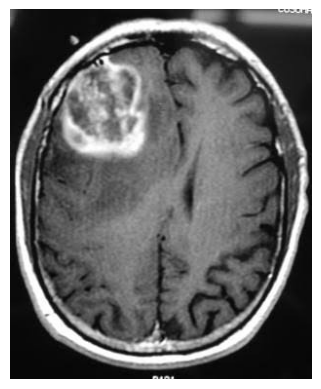

In [19]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(img_path)

print("Loaded:", img is not None)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

In [20]:
import numpy as np

img_resized = cv2.resize(img, (224, 224))
img_array = np.expand_dims(img_resized / 255.0, axis=0)

print(img_array.shape)

(1, 224, 224, 3)


In [21]:
for layer in final_model.layers:
    print(layer.name, layer.__class__.__name__)

input_layer InputLayer
rescaling Rescaling
normalization Normalization
rescaling_1 Rescaling
stem_conv_pad ZeroPadding2D
stem_conv Conv2D
stem_bn BatchNormalization
stem_activation Activation
block1a_dwconv DepthwiseConv2D
block1a_bn BatchNormalization
block1a_activation Activation
block1a_se_squeeze GlobalAveragePooling2D
block1a_se_reshape Reshape
block1a_se_reduce Conv2D
block1a_se_expand Conv2D
block1a_se_excite Multiply
block1a_project_conv Conv2D
block1a_project_bn BatchNormalization
block2a_expand_conv Conv2D
block2a_expand_bn BatchNormalization
block2a_expand_activation Activation
block2a_dwconv_pad ZeroPadding2D
block2a_dwconv DepthwiseConv2D
block2a_bn BatchNormalization
block2a_activation Activation
block2a_se_squeeze GlobalAveragePooling2D
block2a_se_reshape Reshape
block2a_se_reduce Conv2D
block2a_se_expand Conv2D
block2a_se_excite Multiply
block2a_project_conv Conv2D
block2a_project_bn BatchNormalization
block2b_expand_conv Conv2D
block2b_expand_bn BatchNormalization
bloc

In [22]:
final_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,543,025 (17.33 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 328,970 (1.25 MB)

In [23]:
for i, layer in enumerate(final_model.layers):
    print(i, layer.name, layer.__class__.__name__)

0 input_layer InputLayer
1 rescaling Rescaling
2 normalization Normalization
3 rescaling_1 Rescaling
4 stem_conv_pad ZeroPadding2D
5 stem_conv Conv2D
6 stem_bn BatchNormalization
7 stem_activation Activation
8 block1a_dwconv DepthwiseConv2D
9 block1a_bn BatchNormalization
10 block1a_activation Activation
11 block1a_se_squeeze GlobalAveragePooling2D
12 block1a_se_reshape Reshape
13 block1a_se_reduce Conv2D
14 block1a_se_expand Conv2D
15 block1a_se_excite Multiply
16 block1a_project_conv Conv2D
17 block1a_project_bn BatchNormalization
18 block2a_expand_conv Conv2D
19 block2a_expand_bn BatchNormalization
20 block2a_expand_activation Activation
21 block2a_dwconv_pad ZeroPadding2D
22 block2a_dwconv DepthwiseConv2D
23 block2a_bn BatchNormalization
24 block2a_activation Activation
25 block2a_se_squeeze GlobalAveragePooling2D
26 block2a_se_reshape Reshape
27 block2a_se_reduce Conv2D
28 block2a_se_expand Conv2D
29 block2a_se_excite Multiply
30 block2a_project_conv Conv2D
31 block2a_project_bn B

In [24]:
heatmap = make_gradcam_heatmap(
    img_array,
    final_model,
    "top_conv"
)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


In [25]:
last_conv_layer_name = "top_conv"

In [26]:
for layer in final_model.layers:
    if "top_conv" in layer.name:
        print(layer.name)

top_conv


In [27]:
last_conv_layer_name = "top_conv"

In [28]:
for layer in final_model.layers:
    print(layer.name)

input_layer
rescaling
normalization
rescaling_1
stem_conv_pad
stem_conv
stem_bn
stem_activation
block1a_dwconv
block1a_bn
block1a_activation
block1a_se_squeeze
block1a_se_reshape
block1a_se_reduce
block1a_se_expand
block1a_se_excite
block1a_project_conv
block1a_project_bn
block2a_expand_conv
block2a_expand_bn
block2a_expand_activation
block2a_dwconv_pad
block2a_dwconv
block2a_bn
block2a_activation
block2a_se_squeeze
block2a_se_reshape
block2a_se_reduce
block2a_se_expand
block2a_se_excite
block2a_project_conv
block2a_project_bn
block2b_expand_conv
block2b_expand_bn
block2b_expand_activation
block2b_dwconv
block2b_bn
block2b_activation
block2b_se_squeeze
block2b_se_reshape
block2b_se_reduce
block2b_se_expand
block2b_se_excite
block2b_project_conv
block2b_project_bn
block2b_drop
block2b_add
block3a_expand_conv
block3a_expand_bn
block3a_expand_activation
block3a_dwconv_pad
block3a_dwconv
block3a_bn
block3a_activation
block3a_se_squeeze
block3a_se_reshape
block3a_se_reduce
block3a_se_expand

In [29]:
img_path = "/content/drive/MyDrive/brain_tumor_dataset/Training/glioma_tumor/gg (625).jpg"

In [30]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

IMG_SIZE = 224

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

input_image = np.expand_dims(img_resized, axis=0)
input_image = input_image.astype("float32")

In [31]:
last_conv_layer_name = "top_conv"

grad_model = tf.keras.models.Model(
    [final_model.inputs],
    [final_model.get_layer(last_conv_layer_name).output,
     final_model.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(input_image)

    pred_index = tf.argmax(predictions[0])
    class_channel = predictions[:, pred_index]

grads = tape.gradient(class_channel, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

heatmap = heatmap.numpy()

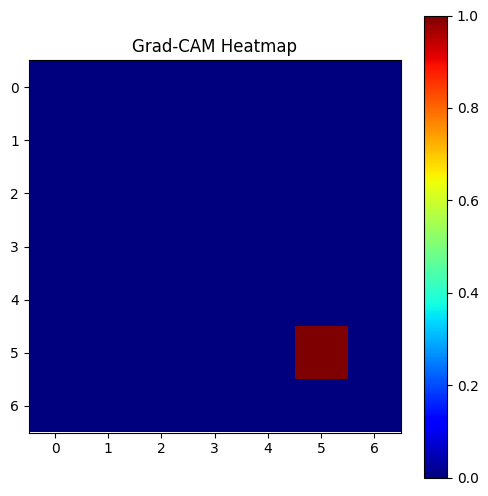

In [32]:
plt.figure(figsize=(6,6))
plt.imshow(heatmap, cmap='jet')
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.show()

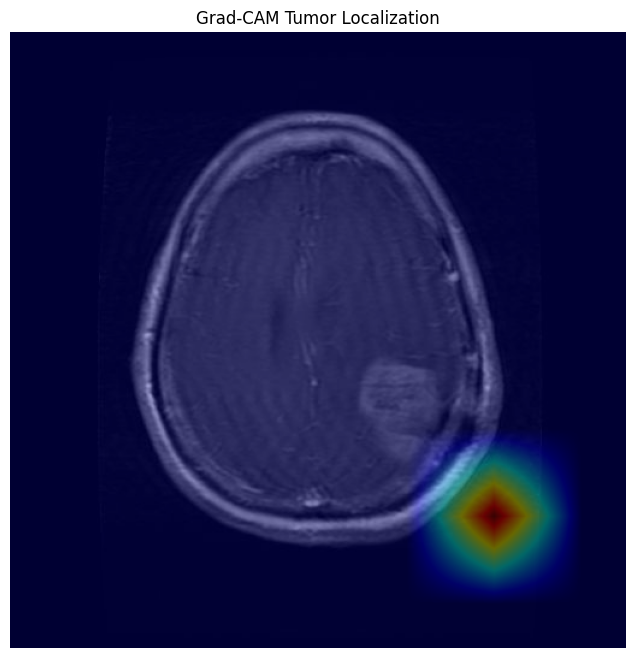

In [33]:
heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

superimposed_img = cv2.addWeighted(
    cv2.cvtColor(img, cv2.COLOR_RGB2BGR),
    0.6,
    heatmap,
    0.4,
    0
)

superimposed_img = cv2.cvtColor(
    superimposed_img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8,8))
plt.imshow(superimposed_img)
plt.title("Grad-CAM Tumor Localization")
plt.axis("off")
plt.show()

In [34]:
class_names = [
    "glioma_tumor",
    "meningioma_tumor",
    "no_tumor",
    "pituitary_tumor"
]

pred = final_model.predict(input_image)

predicted_class = class_names[np.argmax(pred)]

print("Predicted Class:", predicted_class)
print("Confidence:", np.max(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
Predicted Class: meningioma_tumor
Confidence: 0.97158426
